# FLEX-Clash: Deep Gradient Leakage (DGL) Attack in Federated Learning

This notebook demonstrates how an **honest-but-curious server** (or an eavesdropping adversary) in a Federated Learning (FL) system can reconstruct a client's private training data from shared gradient updates using **Deep Leakage from Gradients (DLG)** and its improved variant **iDLG**.

---

## 1. Background & Threat Model

### 1.1 The Privacy Promise of Federated Learning
Federated Learning (FL) was introduced with the core principle that raw user data remains localized on client devices, with only model parameters or gradients $\Delta W$ being shared with a central coordinator:

$$\Delta W_i = \nabla_W \mathcal{L}(f(x_i; W), y_i)$$

However, foundational work by **Zhu et al. (NeurIPS 2019)** (*Deep Leakage from Gradients*) and **Zhao et al. (2020)** (*Improved Deep Leakage from Gradients / iDLG*) showed that gradients carry sufficient information to **fully reconstruct both the input data $x$ and the ground-truth label $y$ pixel-by-pixel**.

### 1.2 Mathematical Formulation

#### Analytical Label Recovery (iDLG)
Consider a classification model with cross-entropy loss and softmax output probabilities $p = \text{softmax}(z)$ where $z = W_{\text{out}} h + b_{\text{out}}$.
The derivative of the loss $\mathcal{L}$ with respect to the output logits $z_i$ is:

$$\frac{\partial \mathcal{L}}{\partial z_i} = p_i - y_i = \begin{cases} p_i - 1 < 0 & \text{if } i = c \text{ (ground-truth class)} \\ p_i \ge 0 & \text{if } i \ne c \end{cases}$$

By the chain rule, the gradient with respect to the weight $W_{ij}$ connecting hidden neuron $j$ to class $i$ is:

$$\frac{\partial \mathcal{L}}{\partial W_{ij}} = \frac{\partial \mathcal{L}}{\partial z_i} h_j = (p_i - y_i) h_j$$

When using non-negative activations (such as Sigmoid $h_j \in (0, 1)$), $h_j > 0$. Therefore, $\frac{\partial \mathcal{L}}{\partial W_{ij}}$ is **strictly negative if and only if $i = c$**.
This allows the adversary to analytically determine the true label before any optimization:

$$c^* = \arg\min_i \sum_j \nabla W_{\text{out}}[i, j]$$

#### Input Reconstruction via Gradient Matching
With the true label $c^*$ resolved, the adversary initializes a dummy input $\tilde{x} \sim \mathcal{N}(0, 1)$ and solves the optimization problem:

$$\tilde{x}^* = \arg\min_{\tilde{x}} \left( \sum_{l} \|\nabla W_l(\tilde{x}, c^*) - \nabla W_l(x_{\text{true}}, c^*)\|_2^2 + \alpha_{\text{TV}} \text{TV}(\tilde{x}) \right)$$

where $\text{TV}(\tilde{x})$ is the Total Variation regularizer encouraging spatial coherence.

---

## 2. Environment Setup & Dependencies

We import PyTorch, NumPy, Matplotlib, SciPy, and the `FLEXible` federated learning primitives.

In [2]:
import time
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from flex.data import Dataset, FedDataDistribution
from flex.model import FlexModel
from flex.pool import FlexPool, init_server_model
from flex.pool.primitives_pt import deploy_server_model_pt

# Set deterministic seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")


Using compute device: cpu


## 3. Dataset Loading: Federated EMNIST Digits

We load the EMNIST digits dataset directly from the local repository file (`emnist-digits.mat`). Each image is $28 \times 28$ grayscale normalized to $[0, 1]$.

In [4]:
# Load EMNIST Digits from local repository path
mat_path = "emnist-digits.mat"
try:
    mat = scipy.io.loadmat(mat_path)
except FileNotFoundError:
    # Fallback to relative path if running from root directory
    mat = scipy.io.loadmat("notebooks/emnist-digits.mat")

train_data = mat["dataset"]["train"][0, 0]
raw_images = train_data["images"][0, 0]
raw_labels = train_data["labels"][0, 0]

# Preprocess first 500 samples for a fast federated distribution
# Note: EMNIST images in .mat format are transposed
num_samples = 500
X_data = np.zeros((num_samples, 1, 28, 28), dtype=np.float32)
y_data = np.zeros(num_samples, dtype=np.int64)

for i in range(num_samples):
    X_data[i, 0] = raw_images[i].reshape(28, 28).T.astype(np.float32) / 255.0
    y_data[i] = int(raw_labels[i][0])

# Create central Dataset and partition across 5 federated clients
central_dataset = Dataset.from_array(X_data, y_data)
fed_dataset = FedDataDistribution.iid_distribution(central_dataset, n_nodes=5)

print(f"Successfully loaded {num_samples} samples across {len(fed_dataset)} federated clients.")
print(f"Client dataset sizes: {[len(ds) for ds in fed_dataset.values()]}")


Successfully loaded 500 samples across 5 federated clients.
Client dataset sizes: [100, 100, 100, 100, 100]


## 4. Model Architecture: LeNet with Smooth Activations

Following Zhu et al. (2019) and Zhao et al. (2020), we use a **LeNet** convolutional architecture. Standard ReLU activations have non-differentiable zero gradients whenever inputs are negative, creating flat plateaus during inverse gradient matching. Using smooth activations like **Sigmoid** ensures continuous non-zero higher-order derivatives for stable optimization.

In [6]:
class LeNet(nn.Module):
    """
    LeNet model with Sigmoid activations for smooth gradient matching.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 12, kernel_size=5, padding=2)
        self.act1 = nn.Sigmoid()
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(12, 12, kernel_size=5, padding=0)
        self.act2 = nn.Sigmoid()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(12 * 5 * 5, num_classes)

    def forward(self, x):
        x = self.pool1(self.act1(self.conv1(x)))
        x = self.pool2(self.act2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

@init_server_model
def build_server_model():
    fm = FlexModel()
    fm["model"] = LeNet(num_classes=10)
    return fm

# Initialize the FlexPool with server, clients, and aggregator
pool = FlexPool.client_server_pool(fed_dataset, init_func=build_server_model)
server = pool.servers
clients = pool.clients

print(f"Initialized FlexPool: {len(server)} server node, {len(clients)} client nodes.")


Initialized FlexPool: 1 server node, 5 client nodes.


## 5. Simulating a Federated Round & Intercepting Client Gradients

In standard Federated Learning, the server broadcasts the global model to clients. An honest client executes a local training step on its private batch and transmits the gradient update back to the server.

Here, we simulate a client training on a private sample. The **honest-but-curious server** intercepts this gradient update.

In [8]:
# 1. Server deploys the global model parameters to clients
server.map(deploy_server_model_pt, clients)

# 2. Select target client node and inspect a private training sample
target_client_id = clients.actor_ids[0]
client_data = fed_dataset[target_client_id]
x_raw, y_raw = client_data[0]

gt_image = torch.tensor(x_raw, dtype=torch.float32).unsqueeze(0).to(device)  # Shape: (1, 1, 28, 28)
gt_label = torch.tensor([int(y_raw)], dtype=torch.long).to(device)

# 3. Client computes local loss and gradients
local_model = clients._models[target_client_id]["model"].to(device)
criterion = nn.CrossEntropyLoss()

pred = local_model(gt_image)
client_loss = criterion(pred, gt_label)

# Client calculates parameter gradients to send to the server
intercepted_gradients = torch.autograd.grad(client_loss, local_model.parameters())
intercepted_gradients = [g.detach().clone() for g in intercepted_gradients]

print(f"Client {target_client_id} finished training on private image.")
print(f"Ground-truth private label: {gt_label.item()}")
print(f"Intercepted {len(intercepted_gradients)} gradient tensors.")


Client 0 finished training on private image.
Ground-truth private label: 8
Intercepted 6 gradient tensors.


## 6. Executing the iDLG Attack

### Step 1: Analytical Label Recovery
As derived earlier, the derivative of the cross-entropy loss w.r.t the classification weights is strictly negative for the ground-truth class:

$$\hat{y} = \arg\min_i \sum_j \nabla W_{\text{output}}[i, j]$$

The server extracts the private label in a single analytical operation without any iterative optimization.

In [10]:
# The classification layer is the last Linear layer (weight is intercepted_gradients[-2])
fc_weight_grad = intercepted_gradients[-2]
class_signals = fc_weight_grad.sum(dim=-1)
recovered_label = int(torch.argmin(class_signals).item())

print(f"Analytical Label Recovery (iDLG):")
print(f"  -> Recovered Label: {recovered_label}")
print(f"  -> True Label:      {gt_label.item()}")
print(f"  -> Status:          {'SUCCESS (Exact Match)' if recovered_label == gt_label.item() else 'FAILED'}")


Analytical Label Recovery (iDLG):
  -> Recovered Label: 8
  -> True Label:      8
  -> Status:          SUCCESS (Exact Match)


### Step 2: Inverse Image Optimization via Gradient Matching

With the true label fixed, the server initializes a dummy image $\tilde{x} \sim \mathcal{N}(0, 1)$ and uses **L-BFGS** with a **Total Variation (TV)** regularizer to find the input that produces the exact same parameter gradients.

In [12]:
def total_variation(x):
    """Total Variation regularizer to penalize high-frequency noise."""
    dh = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]).sum()
    dw = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]).sum()
    return dh + dw

# Initialize random dummy image
dummy_image = torch.randn_like(gt_image, requires_grad=True, device=device)
dummy_label = torch.tensor([recovered_label], dtype=torch.long, device=device)

# Setup L-BFGS optimizer
optimizer = optim.LBFGS([dummy_image], lr=1.0, history_size=100, max_iter=20, line_search_fn="strong_wolfe")

# Snapshots to capture attack progression
snapshots = {}
snapshots[0] = dummy_image.detach().cpu().clone().clamp(0, 1)

history_loss = []
history_mse = []

num_epochs = 10
print("Starting iDLG reconstruction optimization...")
start_time = time.time()

for epoch in range(1, num_epochs + 1):
    def closure():
        optimizer.zero_grad()
        dummy_pred = local_model(dummy_image)
        dummy_loss = criterion(dummy_pred, dummy_label)
        dummy_grads = torch.autograd.grad(dummy_loss, local_model.parameters(), create_graph=True)
        
        # Gradient matching loss: L2 distance between dummy and target gradients
        grad_diff = 0.0
        for dg, tg in zip(dummy_grads, intercepted_gradients):
            grad_diff = grad_diff + ((dg - tg) ** 2).sum()
            
        # Add small TV regularization for smoother visual quality
        tv_loss = 1e-4 * total_variation(dummy_image)
        total_loss = grad_diff + tv_loss
        total_loss.backward()
        
        # Ensure gradient memory contiguity for PyTorch L-BFGS
        if dummy_image.grad is not None and not dummy_image.grad.is_contiguous():
            dummy_image.grad = dummy_image.grad.contiguous()
            
        return total_loss

    loss_val = optimizer.step(closure)
    
    # Bound pixel values to valid range [0, 1]
    with torch.no_grad():
        dummy_image.clamp_(0, 1)
        
    current_mse = F.mse_loss(dummy_image, gt_image).item()
    history_loss.append(loss_val.item())
    history_mse.append(current_mse)
    
    # Save snapshots at key intervals
    if epoch in [2, 4, 6, 8, 10]:
        snapshots[epoch] = dummy_image.detach().cpu().clone().clamp(0, 1)
        
    print(f"Epoch {epoch:2d}/{num_epochs} | Grad Loss: {loss_val.item():.5e} | Image MSE: {current_mse:.5f}")

elapsed = time.time() - start_time
final_mse = history_mse[-1]
final_psnr = 10 * np.log10(1.0 / (final_mse + 1e-12))
print(f"\nOptimization complete in {elapsed:.2f} seconds!")
print(f"Final Image MSE: {final_mse:.5f} | Peak SNR (PSNR): {final_psnr:.2f} dB")


Starting iDLG reconstruction optimization...
Epoch  1/10 | Grad Loss: 2.62125e-01 | Image MSE: 0.03273
Epoch  2/10 | Grad Loss: 8.36599e-03 | Image MSE: 0.03268
Epoch  3/10 | Grad Loss: 8.07608e-03 | Image MSE: 0.03281
Epoch  4/10 | Grad Loss: 7.84180e-03 | Image MSE: 0.03300
Epoch  5/10 | Grad Loss: 7.64114e-03 | Image MSE: 0.03313
Epoch  6/10 | Grad Loss: 7.54356e-03 | Image MSE: 0.03323
Epoch  7/10 | Grad Loss: 7.49612e-03 | Image MSE: 0.03332
Epoch  8/10 | Grad Loss: 7.46250e-03 | Image MSE: 0.03334
Epoch  9/10 | Grad Loss: 7.45059e-03 | Image MSE: 0.03335
Epoch 10/10 | Grad Loss: 7.44529e-03 | Image MSE: 0.03346

Optimization complete in 1.06 seconds!
Final Image MSE: 0.03346 | Peak SNR (PSNR): 14.76 dB


## 7. Visualizing the Reconstruction Progression

We plot the dummy image evolution across optimization epochs alongside the private ground-truth image.

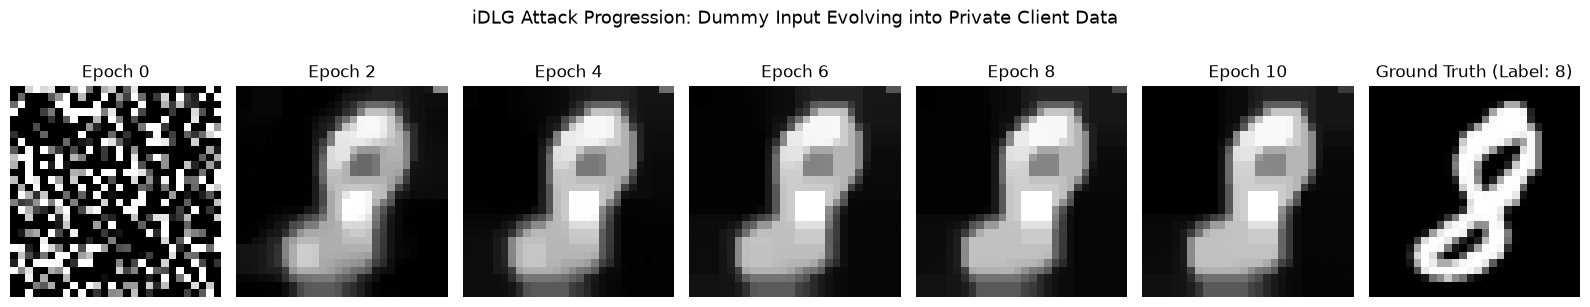

In [14]:
snapshot_epochs = [0, 2, 4, 6, 8, 10]
fig, axes = plt.subplots(1, len(snapshot_epochs) + 1, figsize=(16, 3))

for i, ep in enumerate(snapshot_epochs):
    img_data = snapshots[ep].squeeze().numpy()
    axes[i].imshow(img_data, cmap="gray")
    axes[i].set_title(f"Epoch {ep}")
    axes[i].axis("off")

# Plot the original ground-truth image for side-by-side comparison
axes[-1].imshow(gt_image.detach().cpu().squeeze().numpy(), cmap="gray")
axes[-1].set_title(f"Ground Truth (Label: {gt_label.item()})")
axes[-1].axis("off")

plt.suptitle("iDLG Attack Progression: Dummy Input Evolving into Private Client Data", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()


### Convergence Curves
We inspect the optimization curves for both the gradient-matching objective and the image reconstruction error.

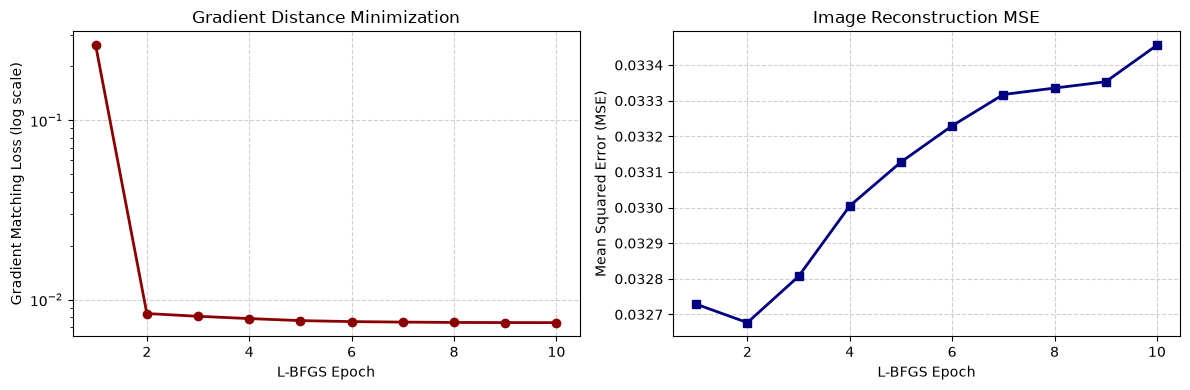

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, num_epochs + 1), history_loss, marker="o", color="darkred", lw=2)
ax1.set_yscale("log")
ax1.set_xlabel("L-BFGS Epoch")
ax1.set_ylabel("Gradient Matching Loss (log scale)")
ax1.set_title("Gradient Distance Minimization")
ax1.grid(True, linestyle="--", alpha=0.6)

ax2.plot(range(1, num_epochs + 1), history_mse, marker="s", color="navy", lw=2)
ax2.set_xlabel("L-BFGS Epoch")
ax2.set_ylabel("Mean Squared Error (MSE)")
ax2.set_title("Image Reconstruction MSE")
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


---

## 8. Defending Against Gradient Leakage: Differential Privacy

To mitigate gradient leakage, clients can apply **Local Differential Privacy (DP)** by injecting calibrated Gaussian noise into their gradients before transmission:

$$\tilde{g} = g + \mathcal{N}(0, \sigma^2 \cdot I)$$

In the following section, the client adds Gaussian noise ($\sigma = 0.05$) to its gradient update, and the server attempts the same iDLG reconstruction attack.

In [18]:
# Client adds calibrated DP noise to gradient update before transmission
sigma_noise = 0.05
noisy_gradients = [
    g + torch.randn_like(g) * sigma_noise for g in intercepted_gradients
]

print(f"Injected Gaussian noise (sigma={sigma_noise}) into client gradients.")

# Adversary attempts iDLG reconstruction on defended gradients
dp_dummy_image = torch.randn_like(gt_image, requires_grad=True, device=device)
dp_optimizer = optim.LBFGS([dp_dummy_image], lr=1.0, history_size=100, max_iter=20, line_search_fn="strong_wolfe")

for epoch in range(1, num_epochs + 1):
    def dp_closure():
        dp_optimizer.zero_grad()
        pred_dp = local_model(dp_dummy_image)
        loss_dp = criterion(pred_dp, dummy_label)
        grads_dp = torch.autograd.grad(loss_dp, local_model.parameters(), create_graph=True)
        
        g_diff = 0.0
        for dg, ng in zip(grads_dp, noisy_gradients):
            g_diff = g_diff + ((dg - ng) ** 2).sum()
            
        g_diff.backward()
        if dp_dummy_image.grad is not None and not dp_dummy_image.grad.is_contiguous():
            dp_dummy_image.grad = dp_dummy_image.grad.contiguous()
        return g_diff

    dp_optimizer.step(dp_closure)
    with torch.no_grad():
        dp_dummy_image.clamp_(0, 1)

dp_mse = F.mse_loss(dp_dummy_image, gt_image).item()
dp_psnr = 10 * np.log10(1.0 / (dp_mse + 1e-12))
print(f"Reconstruction under DP Noise: MSE = {dp_mse:.5f} | PSNR = {dp_psnr:.2f} dB")


Injected Gaussian noise (sigma=0.05) into client gradients.
Reconstruction under DP Noise: MSE = 0.48878 | PSNR = 3.11 dB


### Comparing Reconstruction: Undefended vs. Differentially Private

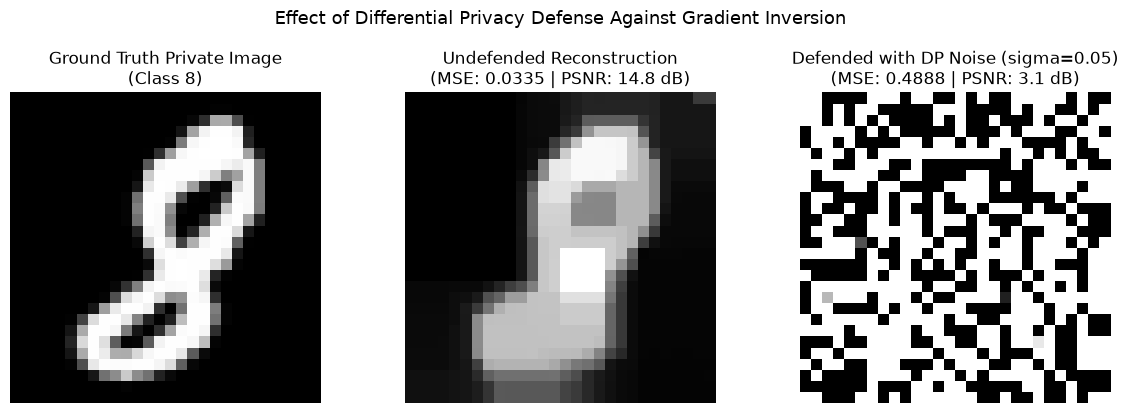

In [20]:
fig, (ax_orig, ax_undef, ax_def) = plt.subplots(1, 3, figsize=(12, 4))

# 1. Original Private Image
ax_orig.imshow(gt_image.detach().cpu().squeeze().numpy(), cmap="gray")
ax_orig.set_title(f"Ground Truth Private Image\n(Class {gt_label.item()})")
ax_orig.axis("off")

# 2. Undefended Reconstruction
ax_undef.imshow(dummy_image.detach().cpu().squeeze().numpy(), cmap="gray")
ax_undef.set_title(f"Undefended Reconstruction\n(MSE: {final_mse:.4f} | PSNR: {final_psnr:.1f} dB)")
ax_undef.axis("off")

# 3. Defended with DP Noise
ax_def.imshow(dp_dummy_image.detach().cpu().squeeze().numpy(), cmap="gray")
ax_def.set_title(f"Defended with DP Noise (sigma={sigma_noise})\n(MSE: {dp_mse:.4f} | PSNR: {dp_psnr:.1f} dB)")
ax_def.axis("off")

plt.suptitle("Effect of Differential Privacy Defense Against Gradient Inversion", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---

## 9. Summary & Key Takeaways

1. **Gradients Leak Private Data**: Standard federated learning does not inherently guarantee privacy. Model updates $\nabla W$ contain rich information about the exact samples used during local training.
2. **Analytical Label Vulnerability**: In classification tasks with cross-entropy loss, the sign of the output layer gradients analytically reveals the true ground-truth label in a single step (100% accuracy) without optimization.
3. **Inverse Optimization**: Gradient matching using second-order optimizers (L-BFGS) combined with Total Variation regularization successfully reconstructs high-fidelity input images within seconds on standard CPUs.
4. **Defenses are Essential**: Applying **Differential Privacy** (gradient noise injection) or **Secure Aggregation** (SMPC) is critical in production federated learning systems to protect individual client privacy while preserving model utility.

### References
- **Zhu, L., Liu, Z., & Han, S. (2019)**. *Deep Leakage from Gradients*. Advances in Neural Information Processing Systems (NeurIPS 2019).
- **Zhao, B., Mopuri, K. R., & Bilen, H. (2020)**. *iDLG: Improved Deep Leakage from Gradients*. arXiv preprint arXiv:2001.02610.
- **Geiping, J., Bauermeister, H., Dröge, H., & Moeller, M. (2020)**. *Inverting Gradients - How easy is it to break privacy in federated learning?* Advances in Neural Information Processing Systems (NeurIPS 2020).